In [402]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

df=pd.read_csv("clean_data/clean_wthr_dt.csv")
print(df.info())
df["ds"] = pd.to_datetime(df["ds"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15173 entries, 0 to 15172
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ds                         15173 non-null  object 
 1   HourlyAltimeterSetting     15173 non-null  float64
 2   HourlyDewPointTemperature  15173 non-null  float64
 3   HourlyDryBulbTemperature   15173 non-null  float64
 4   HourlyPrecipitation        15173 non-null  float64
 5   HourlyRelativeHumidity     15173 non-null  float64
 6   HourlySeaLevelPressure     15173 non-null  float64
 7   HourlyStationPressure      15173 non-null  float64
 8   HourlyVisibility           15173 non-null  float64
 9   HourlyWetBulbTemperature   15173 non-null  float64
 10  HourlyWindDirection        15173 non-null  float64
 11  HourlyWindSpeed            15173 non-null  float64
 12  year                       15173 non-null  float64
 13  month                      15173 non-null  flo

Trend : date

In [403]:

df = df.sort_values("ds").reset_index(drop=True)
df["time_index"] = np.arange(len(df))


Seasonality : 

sine/cosine transformations to encode the periodic patterns in Temperatures having daily (24h) and annual (365d) cycles.


In [404]:
# Daily (24-hour cycle)
df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)

# Annual (12-month or 365-day cycle)
df["day_of_year"] = df["ds"].dt.dayofyear
df["sin_year"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_year"] = np.cos(2 * np.pi * df["day_of_year"] / 365)


checking which lags are most meaningful

<Figure size 1000x400 with 0 Axes>

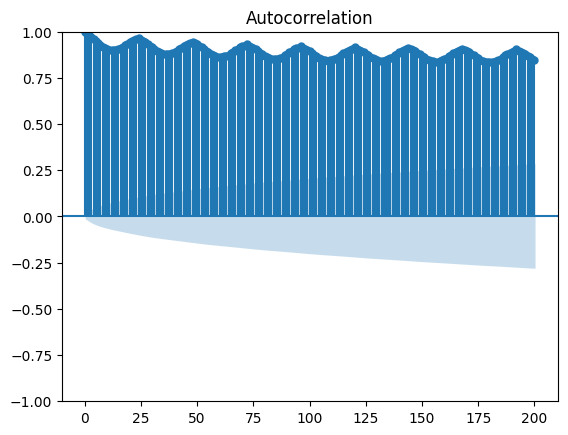

In [405]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df["HourlyDryBulbTemperature"].dropna(), lags=200)
plt.show()


correlation matrix

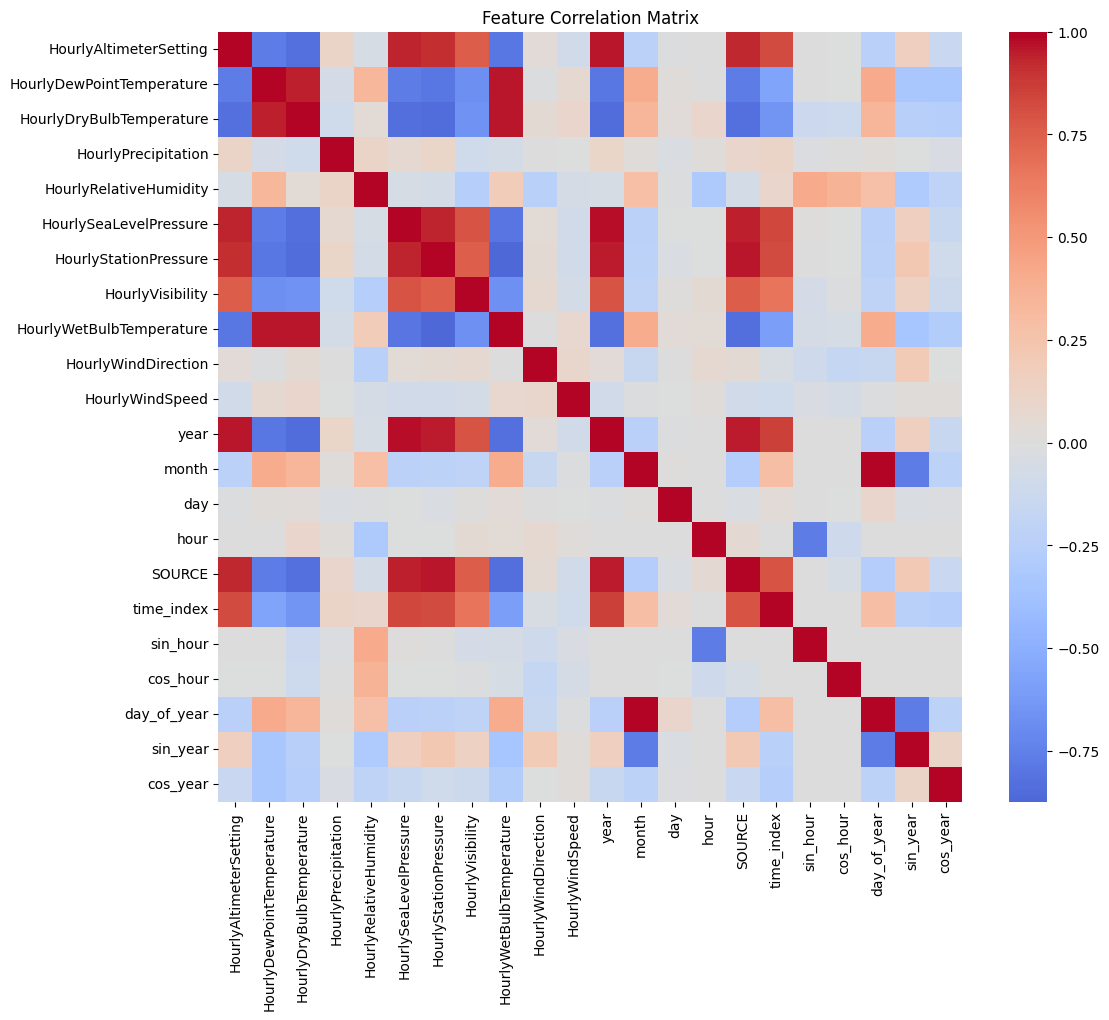

In [406]:
import seaborn as sns

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Focus on correlations with the target (HourlyDryBulbTemperature)
target_corr = corr["HourlyDryBulbTemperature"].sort_values(ascending=False)

# Optional: visualize full correlation matrix heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix")
plt.show()


Target and Features

In [ ]:

# Adding lag features
for l in [1, 3, 6, 12, 24, 168]:
    df[f"temp_lag{l}"] = df["HourlyDryBulbTemperature"].shift(l)


# Drop NaNs and retrain
df = df.dropna().reset_index(drop=True)

## Adding interactions
df["dew_hum"]  = df["HourlyDewPointTemperature"] * df["HourlyRelativeHumidity"]
df["wind_vis"] = df["HourlyWindSpeed"] * df["HourlyVisibility"]
df["sin_hour_hum"] = df["sin_hour"] * df["HourlyRelativeHumidity"]  # diurnal × humidity

# Target variable
y = df["HourlyDryBulbTemperature"]

# Select useful predictors
feature_cols = [
    "HourlyAltimeterSetting", "HourlyDewPointTemperature", "HourlyPrecipitation",
    "HourlyRelativeHumidity", "HourlySeaLevelPressure", "HourlyStationPressure",
    "HourlyVisibility", "HourlyWetBulbTemperature", "HourlyWindDirection", "HourlyWindSpeed",
    "sin_hour", "cos_hour", "sin_year", "cos_year",
    "dew_hum", "wind_vis" ,"sin_hour_hum",
    "time_index", "sin_hour", "cos_hour", "sin_year", "cos_year" ,'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_lag12', 'temp_lag24', 'temp_lag168'
]

X = df[feature_cols]

split = int(len(df) * 0.8)  # 80% of data length

# Training = first 80%, Testing = last 20%
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


# # Train-test split (with masking for dates)
# train_mask = df["ds"] < "2025-09-17"
# test_mask  = (df["ds"] >= "2025-09-17") & (df["ds"] <= "2025-09-30")

# X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, "HourlyDryBulbTemperature"]
# X_test,  y_test  = df.loc[test_mask,  feature_cols], df.loc[test_mask,  "HourlyDryBulbTemperature"]


print(X_train.tail())

       HourlyAltimeterSetting  HourlyDewPointTemperature  HourlyPrecipitation  \
11999             1016.300000                        6.1             0.000000   
12000             1015.600000                        6.1             0.000000   
12001              732.680918                        6.7             0.069097   
12002             1015.200000                        6.1             0.000000   
12003             1015.600000                        6.1             0.000000   

       HourlyRelativeHumidity  HourlySeaLevelPressure  HourlyStationPressure  \
11999                    36.0                  1015.9                1000.30   
12000                    34.0                  1015.2                 999.70   
12001                    33.0                  1015.2                 999.85   
12002                    32.0                  1014.9                 999.30   
12003                    33.0                  1015.1                 999.70   

       HourlyVisibility  HourlyW

Linear Regression Model

In [408]:

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Model Performance

In [409]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²: {r2:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")


R²: 0.825
MSE: 4.861
RMSE: 2.205


Visualizations

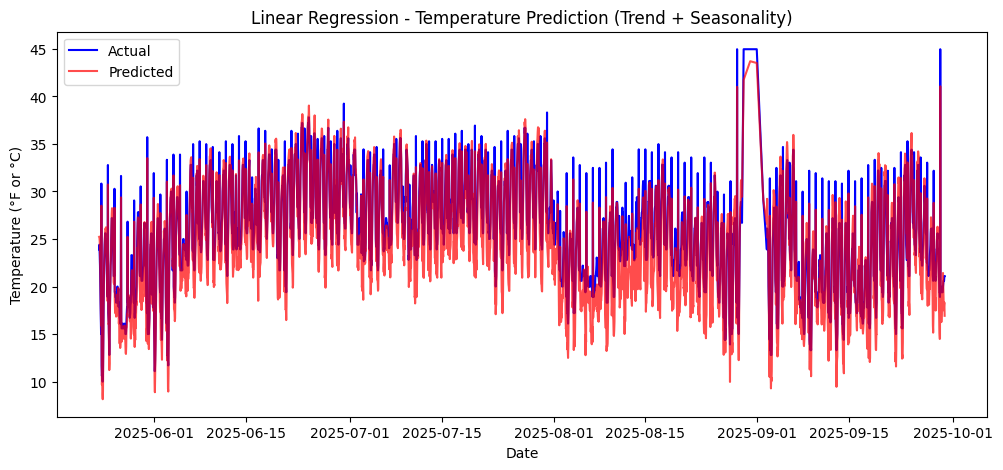

In [410]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["ds"].iloc[-len(y_test):], y_test, label="Actual", color="blue")
plt.plot(df["ds"].iloc[-len(y_test):], y_pred, label="Predicted", color="red", alpha=0.7)
plt.legend()
plt.title("Linear Regression - Temperature Prediction (Trend + Seasonality)")
plt.xlabel("Date")
plt.ylabel("Temperature (°F or °C)")
plt.show()
